# CSCE 40103 Module 5 - Assignment 4
## Assignment 4: Network Anomaly Detection

**Dataset used:** IoT_Intrusion.csv

Date - Jun 27 2026
Name - Bryant Baum


# Dataset Loading and Inspection
Load IoT_Intrusion.csv and inspect its structure before doing any modeling.
1. Load IoT_Intrusion.csv into a dataframe.
2. Display the first five rows.
3. Display the number of rows and columns.
4. Display column names and data types.
5. Check missing values by column.
6. Check duplicate rows.
7. Display class counts and class percentages for label.
----
Required outputs:
• First five rows
• Shape of the dataset
• Column names and data types
• Missing value summary
• Duplicate row count
• Class distribution table for label

In [348]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV = Path("IoT_Intrusion.csv")
RANDOM_STATE = 40103

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


In [349]:
def load_dataset(local_csv: Path = LOCAL_CSV) -> pd.DataFrame:
    # Load the PDF malware dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")

    return loaded_df


df = load_dataset()
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.tail(5)

Loading local CSV file: IoT_Intrusion.csv
Dataset loaded successfully.
Shape: (1048575, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
1048570,1.391925,108.00,6.0,64.00,1.437685,1.437685,0.0,0,1,0,0,0,0,0,0.0,2.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.00,54.0,54.000000,0.000000,54.00,8.336550e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1048571,0.000000,2.14,46.7,65.91,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,6193.32,569.32,592.0,590.691450,5.281048,588.22,8.367732e+07,9.5,34.370618,7.497140,469.190222,0.06,141.55,Mirai-greeth_flood
1048572,0.132971,30847.00,17.0,64.00,5978.034950,5978.034950,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,525.00,50.00,50.0,50.000000,0.000000,50.00,8.312373e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
1048573,0.000000,54.00,6.0,64.00,25.672981,25.672981,0.0,1,0,1,0,0,0,0,1.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.00,54.0,54.000000,0.000000,54.00,8.334509e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-RSTFINFlood
1048574,128.443556,4264.30,7.1,98.80,13.640648,13.640648,0.0,0,0,0,0,1,0,0,0.0,1.2,0.0,6.1,11.4,0,1,0,0,0,0,0,1,0,0,0,0,1,1,2246.40,66.00,441.0,146.402978,114.400450,96.70,1.665173e+08,13.5,17.124571,162.030508,13140.079760,1.00,244.60,BenignTraffic


In [350]:
print('Dataset source: IoT_Intrusion.csv')
print('\nColumns & Data types:')
display(df.dtypes.to_frame('dtype'))

Dataset source: IoT_Intrusion.csv

Columns & Data types:


,dtype
flow_duration,float64
Header_Length,float64
Protocol Type,float64
Duration,float64
Rate,float64
Srate,float64
Drate,float64
fin_flag_number,int64
syn_flag_number,int64
rst_flag_number,int64


In [351]:
# df = df.replace([np.inf,-np.inf], np.nan) use this later
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print('Duplicate rows:', duplicate_count)
print('\nMissing values:')
display(missing_summary[missing_summary > 0].to_frame('missing_count'))

if missing_summary.sum() == 0:
    print('No missing values found.')

df.drop_duplicates(inplace=True)
print("Duplicate values dropped, new shape: ", df.shape)

Duplicate rows: 65556

Missing values:


,missing_count


No missing values found.
Duplicate values dropped, new shape:  (983019, 47)


In [352]:
class_distribution_table = pd.DataFrame({
    'Count': df['label'].value_counts(),
    'Percentage (%)': (df['label'].value_counts(normalize=True) * 100).round(3)
})

print(class_distribution_table)



                          Count  Percentage (%)
label                                          
DDoS-ICMP_Flood          137288          13.966
DDoS-UDP_Flood           121205          12.330
DDoS-TCP_Flood            92028           9.362
DDoS-SYN_Flood            86191           8.768
DDoS-PSHACK_Flood         83914           8.536
DDoS-SynonymousIP_Flood   78994           8.036
DDoS-RSTFINFlood          78439           7.979
DoS-UDP_Flood             74138           7.542
DoS-TCP_Flood             57493           5.849
DoS-SYN_Flood             44389           4.516
BenignTraffic             24476           2.490
Mirai-greeth_flood        21817           2.219
Mirai-udpplain            20166           2.051
Mirai-greip_flood         16746           1.704
DDoS-ICMP_Fragmentation   10216           1.039
MITM-ArpSpoofing           7019           0.714
DDoS-UDP_Fragmentation     6431           0.654
DDoS-ACK_Fragmentation     6429           0.654
DNS_Spoofing               4034         

# 2. Binary Label Construction and Class Distribution

Create a binary evaluation label and inspect the class distribution. This binary label must not be
used as a training feature.
1. Create binary_label where BenignTraffic = 0 and all other label values = 1.
2. Display the distribution of binary_label.
3. Create one plot showing normal versus attack records.
4. Create one plot showing the top attack categories in label.
5. Briefly explain whether the dataset is balanced or imbalanced.
---
Required outputs:
• binary_label value counts and percentages
• Normal versus attack distribution plot
• Top attack category distribution plot
• Short class imbalance explanation

### Make a source_label column

just in case I need it for reference

In [353]:
df["source_label"] = df["label"]

Convert `BenignTraffic` to 0 and everything else to 1

In [354]:
normal_traffic = ["BenignTraffic"]
df["label"] = np.where(df["label"].isin(normal_traffic), 0, 1)
df.head(5)

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label,source_label
0,0.000000,54.00,6.00,64.00,0.329807,0.329807,0.0,1,0,1,0,0,0,0,1.0,0.00,1.00,0.0,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.00,54.0,54.000000,0.000000,54.00,83343831.92,9.5,10.392305,0.000000,0.000000,0.00,141.55,1,DDoS-RSTFINFlood
1,0.000000,57.04,6.33,64.00,4.290556,4.290556,0.0,0,0,0,0,0,0,0,0.0,0.00,0.00,0.0,0.00,1,0,0,0,0,0,0,1,0,0,0,0,1,1,581.33,54.00,66.3,54.796404,2.822973,57.04,82926067.47,9.5,10.464666,4.010353,160.987842,0.05,141.55,1,DoS-TCP_Flood
2,0.000000,0.00,1.00,64.00,33.396799,33.396799,0.0,0,0,0,0,0,0,0,0.0,0.00,0.00,0.0,0.00,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.00,42.00,42.0,42.000000,0.000000,42.00,83127993.93,9.5,9.165151,0.000000,0.000000,0.00,141.55,1,DDoS-ICMP_Flood
3,0.328175,76175.00,17.00,64.00,4642.133010,4642.133010,0.0,0,0,0,0,0,0,0,0.0,0.00,0.00,0.0,0.00,0,0,0,0,0,0,0,0,1,0,0,0,1,1,525.00,50.00,50.0,50.000000,0.000000,50.00,83015696.38,9.5,10.000000,0.000000,0.000000,0.00,141.55,1,DoS-UDP_Flood
4,0.117320,101.73,6.11,65.91,6.202211,6.202211,0.0,0,1,0,0,0,0,0,0.0,1.01,0.04,0.0,0.02,0,0,0,0,0,0,0,1,0,0,0,0,1,1,644.60,57.88,131.6,67.959230,23.113111,57.88,82972999.18,9.5,11.346876,32.716243,3016.808286,0.19,141.55,1,DoS-SYN_Flood


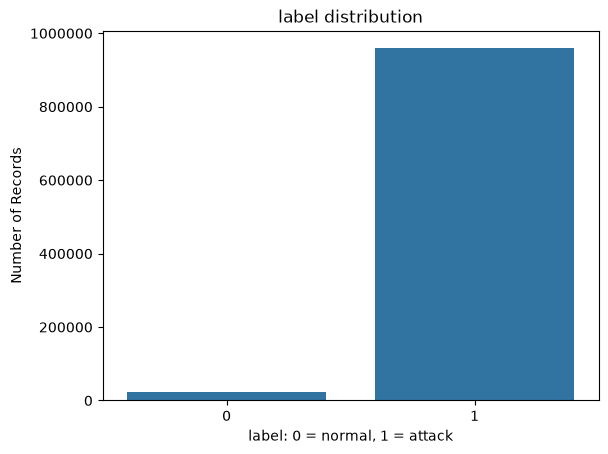

In [355]:
ax = sns.countplot(data=df, x="label")
# do this because I don't want to see numbers in scientific notation form
ax.ticklabel_format(style="plain", axis="y")  
plt.title("label distribution")
plt.xlabel("label: 0 = normal, 1 = attack")
plt.ylabel("Number of Records")
plt.show()

Text(0, 0.5, 'Number of Records')

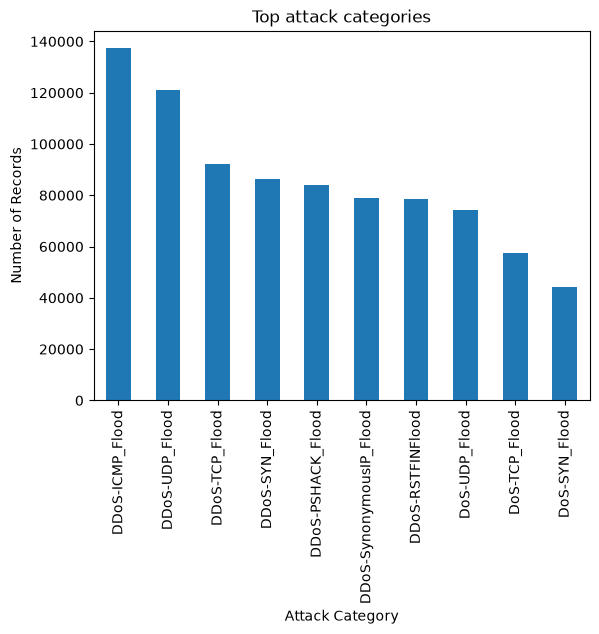

In [356]:
plt.title("Top attack categories")
df['source_label'].value_counts().head(10).plot(kind='bar')
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")

### Explanation

- The dataset is imbalanced, there are far more attack records than benign records and even categorically `BenignTraffic` does not appear in the top 10 categories 

# 3. Data Cleaning and Feature Selection

In [357]:
df = df.replace([np.inf,-np.inf], np.nan)
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print('Duplicate rows:', duplicate_count)
print('\nMissing values:')
display(missing_summary[missing_summary > 0].to_frame('missing_count'))

if missing_summary.sum() == 0:
    print('No missing values found.')

Duplicate rows: 0

Missing values:


,missing_count


No missing values found.


In [358]:
feature_columns = ['flow_duration', 'Header_Length', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']
df_feature = df[feature_columns].copy()

feature_table = [
    {
        "Feature or Feature Group": "flow_duration",
        "Reason for Keeping It": "how long a connection lasts",
        "Possible Network Meaning": "abnormal duration can indicate attack"
    },
    {
        "Feature or Feature Group": "Header_Length",
        "Reason for Keeping It": "total bytes used for protocol headers",
        "Possible Network Meaning": "detects abnormal header size"
    },
    {
        "Feature or Feature Group": "Tot sum, Min, Max, AVG, Std, Tot size, Magnitue",
        "Reason for Keeping It": "Values regarding packet information",
        "Possible Network Meaning": "Packet characteristics give insight into the data flowing in the connection"
    },
    {
        "Feature or Feature Group": "IAT",
        "Reason for Keeping It": "the time intervals between consecutive packets.",
        "Possible Network Meaning": "good for detecting botnets and automated attacks"
    },
    {
        "Feature or Feature Group": "Number",
        "Reason for Keeping It": "the total number of packets in the flow.",
        "Possible Network Meaning": "high counts of packet flow could suggest a ddos attack"
    },
    {
        "Feature or Feature Group": "Radius, Covariance, Variance, Weight",
        "Reason for Keeping It": "these feature are indicative of feature correlation, frequency, and importance",
        "Possible Network Meaning": "Can indicate relationships in the networking data, pointing to steps in an attack instead of just one isolated characteristic"
    },
]

display(pd.DataFrame(feature_table))

,Feature or Feature Group,Reason for Keeping It,Possible Network Meaning
0,flow_duration,how long a connection lasts,abnormal duration can indicate attack
1,Header_Length,total bytes used for protocol headers,detects abnormal header size
2,"Tot sum, Min, Max, AVG, Std, Tot size, Magnitue",Values regarding packet information,Packet characteristics give insight into the d...
3,IAT,the time intervals between consecutive packets.,good for detecting botnets and automated attacks
4,Number,the total number of packets in the flow.,high counts of packet flow could suggest a ddo...
5,"Radius, Covariance, Variance, Weight",these feature are indicative of feature correl...,Can indicate relationships in the networking d...


# 4. Exploratory Feature Analysis
Create visual summaries that help you understand the selected traffic features before anomaly
detection.
1. Create at least four histograms or boxplots for selected numeric features.
2. Create at least one raw versus log-transformed comparison for a highly skewed feature.
3. Create one correlation heatmap using a manageable set of selected numeric features.
4. Create a 2D PCA visualization colored by binary_label for interpretation only.
5. Briefly explain visible patterns, outliers, skewed features, and correlated features.
---
Required outputs:
• At least four feature distribution plots
• One raw versus log-transformed comparison
• One correlation heatmap
• One PCA scatter plot for interpretation only
• Short exploratory interpretation

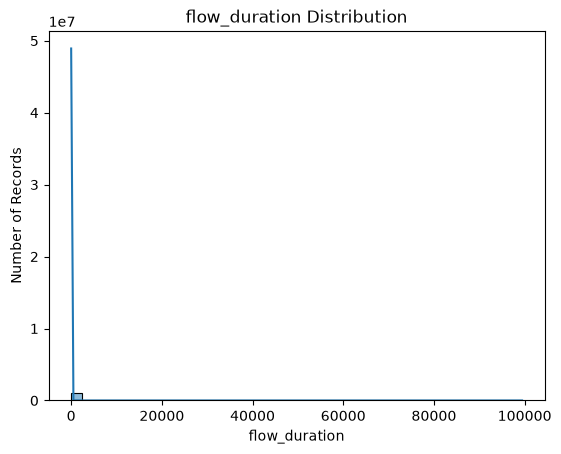

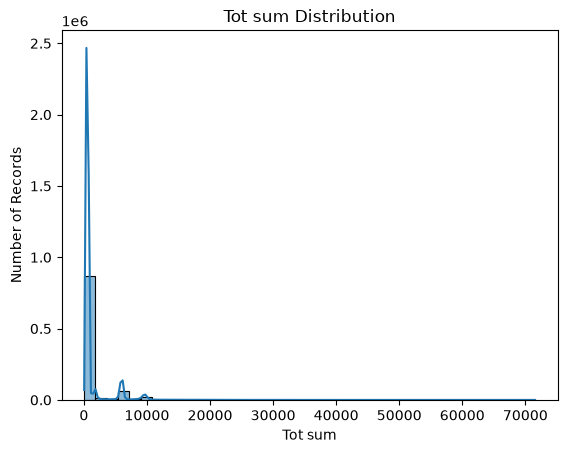

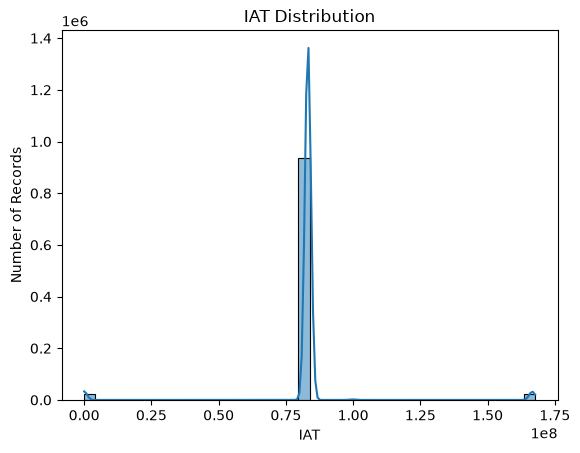

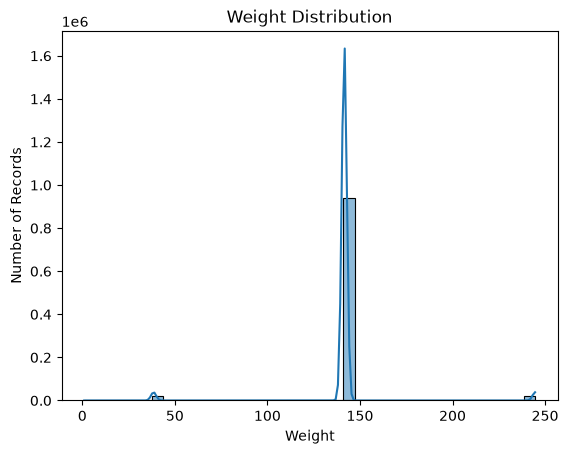

In [359]:
features_to_plot = ["flow_duration", "Tot sum", "IAT", "Weight"]
for feature in features_to_plot:
    if feature in df_feature:
        sns.histplot(data=df_feature, x=feature, bins=40, kde=True)
        plt.title(feature + " Distribution")
        plt.xlabel(feature)
        plt.ylabel("Number of Records")
        plt.show()

### Log transformation of a feature

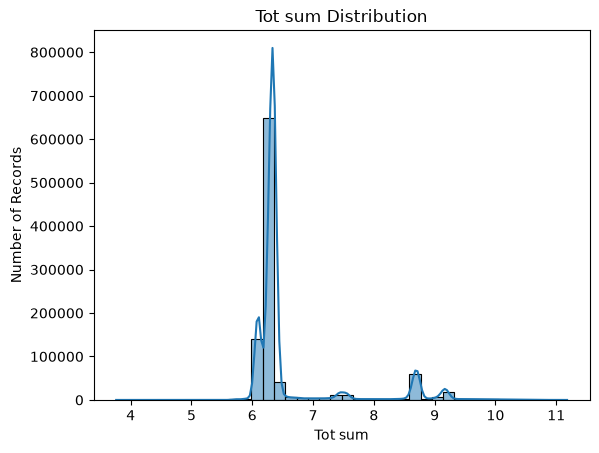

In [360]:
log_feature = "Tot sum"
sns.histplot(data=df_feature, x=np.log1p(df_feature[log_feature]), bins=40, kde=True)
plt.title(log_feature + " Distribution")
plt.xlabel(log_feature)
plt.ylabel("Number of Records")
plt.show()

### Correlation heat map

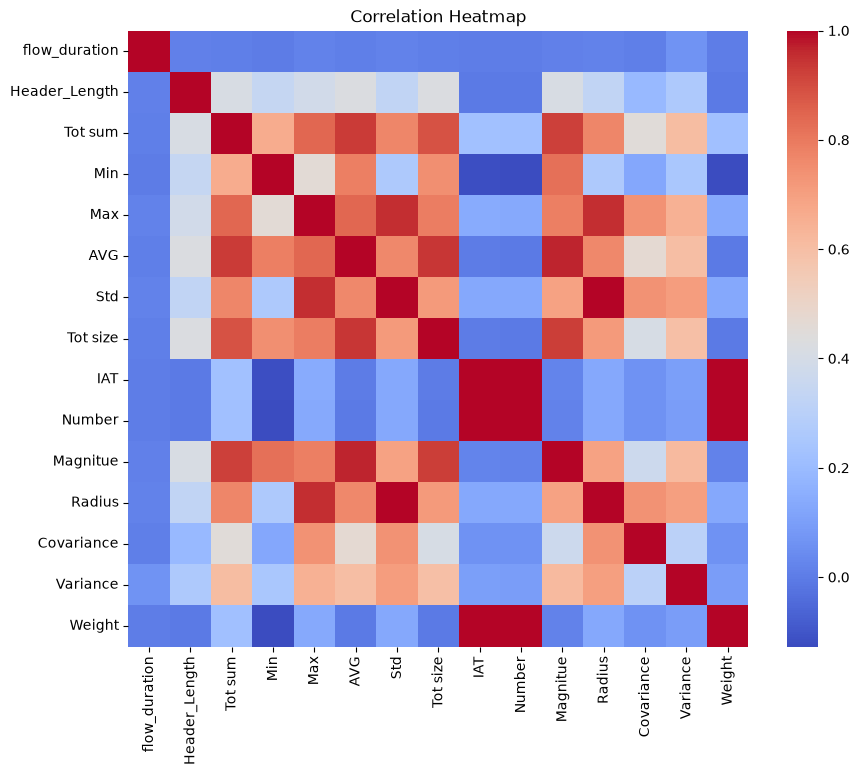

In [361]:
corr_phish = df_feature.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_phish, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 2D PCA visualization colored by binary_label for interpretation only

Explained variance ratio: [9.98797602e-01 7.84731583e-04]


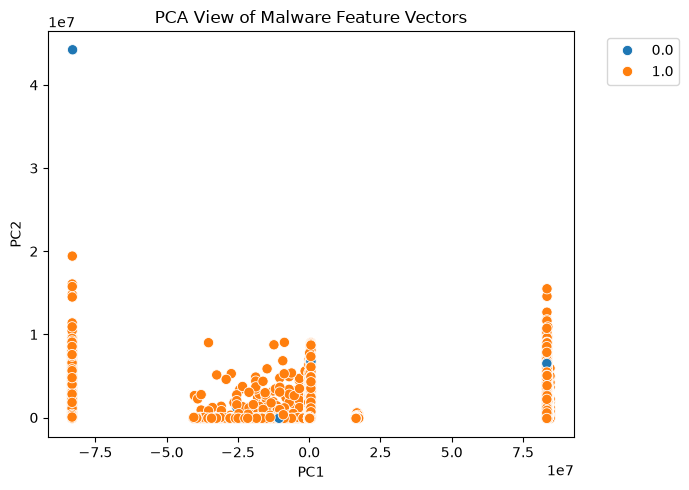

In [362]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(df_feature)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["label"] = df["label"].copy()

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
if "label":
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label", s=55)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=55)
plt.title("PCA View of Malware Feature Vectors")
plt.tight_layout()
plt.show()

- The correlation heat map is showing a strong correlation between the flow_duration and the rest of the features. This makes sense, since less flow would equal less packets and vice versa. IAT and Number are 1:1 which makes me think they represent the same thing. 
- The PCA view confirms what you might intuitively think. There is a lot of attack data that lays way outside of the normal range of values, but sprinkled in there is a couple benign which is part of the challenge when identifying attack behavior from abnormal benign behavior. There is also a large cluster of data that have a mix of benign and attack which in itself will be challenging to differentiate between if there is not an obvious outlier feature. 
- All of the histograms confirm what we are seeing further downstream where the majority of data is fairly concentrated and then there are few really extreme values. 

# 5. Benign Training and Mixed Evaluation Setup
Create a benign training set and a mixed evaluation set. For this assignment, you may use
binary_label only to separate benign records for training and to evaluate results after scoring. Do
not include label, binary_label, or any attack-category information in the feature matrix.
1. Create a benign training set using only records where binary_label = 0.
2. Create a mixed evaluation set containing both normal and attack records.
3. Use controlled samples if the full dataset is too slow. Recommended maximums: 20,000
benign training records and 50,000 mixed evaluation records. Preserve both normal and attack
records in the evaluation set and report sample sizes clearly.
4. Fit StandardScaler only on the benign training features.
5. Transform both the benign training set and the mixed evaluation set using the fitted scaler.
---
Required outputs:
• Benign training size
• Mixed evaluation size
• Evaluation label distribution
• Scaled training and evaluation shapes
• Brief explanation of why scaling is fit only on benign training data

### Create Benign Training Set

In [363]:
x_train = df[df["label"] == 0]
y_train = x_train["label"]
x_train = x_train.drop(columns=["label", "source_label"])
print("Training set size: ", x_train.shape)
x_train.head()

Training set size:  (24476, 46)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
22,37.887028,1687747.1,9.3,63.5,34.048221,34.048221,0.0,0,0,0,0,1,0,0,0.0,0.0,0.0,58.6,1610.8,0,1,0,0,0,0,0,1,0,0,0,0,1,1,2733.2,77.0,817.5,356.406944,332.122451,817.5,5.235219e-03,5.5,24.333355,469.692075,2.092362e+05,0.9,38.5
54,48.272384,128041.4,10.4,97.8,39966.184040,39966.184040,0.0,0,0,0,0,1,0,0,0.0,0.4,0.0,312.5,677.1,0,1,0,0,0,0,0,1,0,0,0,0,1,1,10171.8,55.6,1566.4,661.318481,694.907070,636.4,1.665200e+08,13.5,36.393289,983.968335,4.842123e+05,1.0,244.6
70,48.095663,101026.4,8.8,137.7,13.947935,13.947935,0.0,0,0,0,0,1,0,0,0.0,0.8,0.0,137.9,334.7,0,1,0,0,0,0,0,1,0,0,0,0,1,1,6720.3,156.0,3922.9,1177.511230,1302.117190,919.3,2.724581e-02,5.5,47.214170,1841.471789,2.063959e+06,0.9,38.5
78,46.342407,1301464.8,4.8,168.3,34.223130,34.223130,0.0,0,0,0,0,1,0,0,0.0,1.2,0.0,58.8,1243.2,0,1,0,0,0,0,0,1,0,0,0,0,1,1,361.2,64.8,66.0,65.813333,0.428562,64.8,3.804951e-02,5.5,11.472815,0.606078,9.315556e-01,0.2,38.5
86,88.807750,5290348.6,7.1,63.6,61.443831,61.443831,0.0,0,0,0,0,1,0,0,0.0,1.6,0.0,250.3,5158.3,0,1,0,0,0,0,0,1,0,0,0,0,1,1,7898.4,1227.3,1514.0,1469.563333,101.938534,1227.3,1.833391e-03,5.5,54.184531,144.162858,5.276998e+04,0.2,38.5


### Create Mixed Evaluation Set

label counts:
label
1    30000
0    20000
Name: count, dtype: int64
label percentages:
label
1    60.0
0    40.0
Name: proportion, dtype: float64


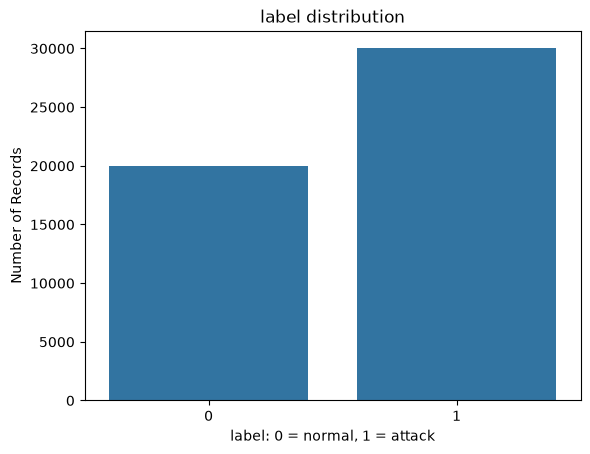

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
0,0.000000,54.00,6.00,64.00,1.195582,1.195582,0.0,0,1,0,0,0,0,0,0.00,1.00,0.0,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.00,54.00,54.000000,0.000000,54.00,8.309018e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55
1,0.731422,77.02,5.94,63.36,1.921562,1.921562,0.0,0,1,0,0,0,0,0,0.00,1.39,0.0,0.00,0.39,0,0,0,0,0,0,0,1,0,0,0,0,1,1,586.78,54.60,58.74,55.874235,1.141371,55.82,8.307699e+07,9.5,10.568867,1.613312,5.492912,0.31,141.55
2,2.724866,24440.50,11.50,133.10,36.823655,36.823655,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,4.50,28.80,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1335.90,50.00,317.00,86.892267,66.927331,65.30,1.665188e+08,13.5,13.191795,94.811203,4519.323648,1.00,244.60
3,0.000000,54.00,6.00,64.00,33.879403,33.879403,0.0,0,1,0,0,0,0,0,0.00,1.00,0.0,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.00,54.00,54.000000,0.000000,54.00,8.308906e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55
4,8.408718,637211.39,5.86,114.06,66.699176,66.699176,0.0,0,0,0,0,1,0,0,0.04,1.76,0.0,38.49,612.82,0,1,0,0,0,0,0,1,0,0,0,0,1,1,10740.37,425.82,2139.93,1114.443249,595.600355,985.80,8.309010e+07,9.5,43.119222,840.051504,475773.677800,0.90,141.55


In [364]:
df_attack = df[df["label"] == 1]
df_benign = df[df["label"] == 0]

df_attack_sampled = df_attack.sample(n=30000, random_state=RANDOM_STATE)
df_benign_sampled = df_benign.sample(n=20000, random_state=RANDOM_STATE)

x_eval = pd.concat([df_attack_sampled, df_benign_sampled])

# shuffle the final dataset
x_eval = x_eval.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

label_counts = x_eval["label"].value_counts()
label_percentages = x_eval["label"].value_counts(normalize=True) * 100
print("label counts:")
print(label_counts)
print("label percentages:")
print(label_percentages.round(2))
sns.countplot(data=x_eval, x="label")
plt.title("label distribution")
plt.xlabel("label: 0 = normal, 1 = attack")
plt.ylabel("Number of Records")
plt.show()

# drop the label after showing the split
y_eval = x_eval["label"]
x_eval = x_eval.drop(columns=["label","source_label"])

x_eval.head()

### Scale and Transform
- only fit benign
- transform both benign and eval

In [365]:
scaler = StandardScaler()
x_train_trans = scaler.fit_transform(x_train)
x_eval_trans = scaler.transform(x_eval)

### Explanation
- Only the benign set is fit, because it teaches the model what to look for and then that fit is applied to the eval to see how it does. 

# 6. Gaussian Anomaly Detection
Use simple statistical anomaly detection on individual numeric features.
1. Choose two meaningful numeric features for z-score detection.
2. At least one selected feature should be related to traffic volume, duration, rate, or packet
behavior.
3. For each selected feature, compute the benign training mean and standard deviation.
4. Compute z-scores for evaluation records.
5. Flag records where the absolute z-score is greater than 3.
6. Evaluate the alert decisions using binary_label after scoring.
Feature Mean Std. Dev. Alerts Precision Recall F1 Interpretation
---
Required outputs:
• Selected two features and explanation
• Top 10 records by absolute z-score for each feature
• Alert counts for each feature
• Metric comparison table for the two features
• Short interpretation of likely false positives or false negatives

In [366]:
def show_top_records(data, score_col, decision_col=None, n=10):
    cols = ["label"] + [score_col] + list(x_eval.columns)
    if decision_col:
        cols.append(decision_col)
    return data[cols].sort_values(score_col, ascending=False).head(n).reset_index(drop=True)

In [367]:
features_to_score = ["flow_duration", "Variance"]

def zScoreFeature(feature):
    mu = x_train[feature].mean()
    sigma = x_train[feature].std(ddof=1)

    z_df = x_eval.copy()
    z_df["label"] = y_eval.values
    z_df["gaussian_z_score"] = (z_df[feature] - mu) / sigma
    z_df["gaussian_anomaly_score"] = z_df["gaussian_z_score"].abs()
    z_df["gaussian_alert"] = z_df["gaussian_anomaly_score"] > 3

    return {
        "zScore": z_df["gaussian_z_score"],
        "anomalyScore": z_df["gaussian_anomaly_score"],
        "alert": z_df["gaussian_alert"],
        "records": show_top_records(z_df, "gaussian_anomaly_score", "gaussian_alert", n=10)
    }

In [368]:
flowData = zScoreFeature(features_to_score[0])
flowData["records"]

,label,gaussian_anomaly_score,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,gaussian_alert
0,1,1857.026208,99435.761780,3677.8,11.4,102.2,1.495516,1.495516,0.0,0,0,0,0,0,0,0,0.0,0.4,0.0,3.2,6.1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,815.6,67.0,232.6,130.127024,68.153206,200.7,1.674650e-02,5.5,15.930322,96.383189,7148.694773,0.9,38.5,True
1,1,1276.079164,68340.722290,181380.1,17.0,2.0,0.005407,0.005407,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,4390.1,66.0,508.2,275.883317,169.176857,484.7,1.664286e+08,13.5,23.385672,239.132225,28720.635460,1.0,244.6,True
2,1,56.132485,3043.393381,82127.4,11.5,56.5,2.955079,2.955079,0.0,0,0,0,0,0,0,0,0.0,0.4,0.0,6.4,25.7,0,0,0,0,0,0,0,0,0,0,0,0,1,1,828.4,66.0,249.6,119.630556,78.495759,248.0,7.486701e-03,5.5,14.920669,111.009768,14966.937830,0.9,38.5,True
3,1,51.487753,2794.785283,11603.2,8.7,160.4,2.386110,2.386110,0.0,0,0,0,0,1,0,0,0.0,0.6,0.0,51.4,87.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,569.1,64.4,200.8,106.310119,49.805573,104.9,2.252450e-02,5.5,14.539481,70.435717,2812.217770,0.9,38.5,True
4,1,40.489963,2206.131439,20406.3,7.7,145.9,16.400700,16.400700,0.0,0,0,0,0,1,0,0,0.0,0.0,0.0,82.9,169.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,581.2,61.5,214.9,110.137143,57.081669,99.3,3.175850e-02,5.5,14.770483,80.725670,3647.644855,0.9,38.5,True
5,1,40.211312,2191.216713,33909.7,8.2,101.7,8.819251,8.819251,0.0,0,0,0,0,1,0,0,0.1,0.8,0.0,98.8,207.5,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1908.8,66.0,333.6,122.019317,77.596671,143.1,1.664379e+08,13.5,15.615397,110.078474,6298.008410,1.0,244.6,True
6,1,36.376453,1985.956892,17609.2,7.1,63.6,3.625667,3.625667,0.0,0,0,0,0,1,0,0,0.0,0.2,0.0,47.7,91.2,0,0,0,0,0,0,0,1,0,0,0,0,1,1,8529.2,58.0,2365.0,563.851941,902.797198,225.7,1.668623e+08,13.5,33.451381,1279.304109,821960.433700,1.0,244.6,True
7,1,28.595827,1569.500932,6138.3,13.7,97.1,2.592510,2.592510,0.0,0,0,0,0,0,0,0,0.0,0.3,0.0,12.9,25.7,0,0,0,0,0,0,0,0,1,0,0,0,1,1,759.5,70.0,280.2,145.580635,77.511017,147.0,2.443471e-02,5.5,16.992661,109.617131,7269.572123,0.9,38.5,True
8,1,25.780208,1418.795609,38277.7,4.9,53.5,16.379682,16.379682,0.0,0,0,0,0,1,0,0,0.5,0.6,0.0,173.2,344.3,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1610.5,54.0,317.0,104.916683,77.457613,79.4,1.664820e+08,13.5,14.459407,109.627792,6042.111908,1.0,244.6,True
9,1,25.445171,1400.862849,49748.6,8.2,131.0,0.281079,0.281079,0.0,0,0,0,0,1,0,0,0.0,0.8,0.0,154.3,325.6,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1618.6,61.6,230.0,104.522780,58.134972,105.9,1.676299e+08,13.5,14.470450,82.343022,3395.930644,1.0,244.6,True


In [369]:
varianceData = zScoreFeature(features_to_score[1])
varianceData["records"]

,label,gaussian_anomaly_score,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,gaussian_alert
0,1,3.599993,0.000000,54.00,6.0,64.0,1.195582,1.195582,0.0,0,1,0,0,0,0,0,0.0,1.00,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83090183.57,9.5,10.392305,0.0,0.0,0.0,141.55,True
1,1,3.599993,0.000000,54.00,6.0,64.0,20.437588,20.437588,0.0,0,1,0,0,0,0,0,0.0,1.00,0.0,0.0,0.0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83094022.78,9.5,10.392305,0.0,0.0,0.0,141.55,True
2,1,3.599993,0.000000,0.00,1.0,64.0,2.699716,2.699716,0.0,0,0,0,0,0,0,0,0.0,0.00,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.0,42.0,42.0,42.0,0.0,42.0,83128979.94,9.5,9.165151,0.0,0.0,0.0,141.55,True
3,1,3.599993,0.000000,54.00,6.0,64.0,40.759274,40.759274,0.0,0,1,0,0,0,0,0,0.0,1.00,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83094155.50,9.5,10.392305,0.0,0.0,0.0,141.55,True
4,1,3.599993,0.000000,0.00,1.0,64.0,12.454349,12.454349,0.0,0,0,0,0,0,0,0,0.0,0.00,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.0,42.0,42.0,42.0,0.0,42.0,83483282.38,9.5,9.165151,0.0,0.0,0.0,141.55,True
5,1,3.599993,0.000000,54.00,6.0,64.0,24.225394,24.225394,0.0,0,1,0,0,0,0,0,0.0,1.00,0.0,0.0,0.0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83090049.13,9.5,10.392305,0.0,0.0,0.0,141.55,True
6,1,3.599993,0.000000,54.00,6.0,64.0,0.400309,0.400309,0.0,0,1,0,0,0,0,0,0.0,1.00,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83089880.66,9.5,10.392305,0.0,0.0,0.0,141.55,True
7,1,3.599993,0.000000,54.00,6.0,64.0,0.399988,0.399988,0.0,0,0,0,1,1,0,0,0.0,0.00,0.0,1.0,1.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83314375.72,9.5,10.392305,0.0,0.0,0.0,141.55,True
8,1,3.599993,0.000000,54.00,6.0,64.0,2.407003,2.407003,0.0,1,0,1,0,0,0,0,1.0,0.00,1.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83343855.69,9.5,10.392305,0.0,0.0,0.0,141.55,True
9,1,3.599993,0.145894,73.98,6.0,64.0,5.222807,5.222807,0.0,0,1,0,0,0,0,0,0.0,1.37,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.0,0.0,54.0,83362095.29,9.5,10.392305,0.0,0.0,0.0,141.55,True


In [370]:
def gaussian_metrics(feature, result):
    mu = x_train[feature].mean()
    sigma = x_train[feature].std(ddof=1)
    alert = result["alert"].astype(int)   # z>3 boolean -> 1/0 prediction
    return {
        "Feature": feature,
        "Mean": round(mu, 4),
        "Std. Dev.": round(sigma, 4),
        "Alerts": int(alert.sum()),
        "Precision": round(precision_score(y_eval, alert, zero_division=0), 4),
        "Recall": round(recall_score(y_eval, alert, zero_division=0), 4),
        "F1": round(f1_score(y_eval, alert, zero_division=0), 4),
    }

metrics_table = pd.DataFrame([
    gaussian_metrics(features_to_score[0], flowData),
    gaussian_metrics(features_to_score[1], varianceData),
])
display(metrics_table)

,Feature,Mean,Std. Dev.,Alerts,Precision,Recall,F1
0,flow_duration,38.9167,53.5247,356,0.2584,0.0031,0.0061
1,Variance,0.8593,0.2387,25747,0.9653,0.8285,0.8917


### Interpretation of false positives / false negatives 
- flow_duration seems to have fallen to the trap that I mentioned earlier in the report that although there was outlier values that may appear as attacks it is very possible that normal behavior could also be responsible. When there is a large majority of traffic operating within a certain. This feature had terrible recall, probably because the majority of attacks are within the standard deviation range

- Variance performed well. A lot of attacks are pretty targeted with their behavior so variance picks up on this lack of change and flags it. 

# Part 7. Isolation Forest
Train Isolation Forest on scaled benign training data and score mixed evaluation records.
1. Train Isolation Forest using the scaled benign training data.
2. Use random_state=40103.
3. Choose a reasonable contamination value and explain your choice as an expected alert budget
or assumed anomaly rate. Do not choose contamination only to maximize label-based
performance.
4. Score the mixed evaluation records.
5. Create an anomaly ranking.
6. Evaluate the alert decisions using binary_label after scoring.
----
Required outputs:
• Isolation Forest parameter settings
• Top 10 records by anomaly score
• Confusion matrix
• Classification report
• Short interpretation of Isolation Forest behavior

In [371]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.04,
    random_state=RANDOM_STATE
)

iso.fit(x_train_trans)
if_df = x_eval.copy()

if_df["label"] = y_eval.values
if_df["isolation_forest_score"] = -iso.decision_function(x_eval_trans)
if_df["isolation_forest_alert"] = iso.predict(x_eval_trans) == -1

show_top_records(if_df, "isolation_forest_score", "isolation_forest_alert", n=10)

,label,isolation_forest_score,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,isolation_forest_alert
0,0,0.189693,87.371366,361609.3,13.7,64.0,85.001226,85.001226,0.0,0,0,0,0,0,0,0,0.0,0.6,0.0,5.7,142.2,0,0,0,0,0,0,0,0,1,0,0,0,1,1,28133.4,1938.8,17442.0,6858.383175,6364.598485,3242.8,5.410004e-03,5.5,113.212734,9000.901497,4.534864e+07,0.9,38.5,True
1,0,0.186826,5.082773,304115.2,2.4,25.6,54.475808,54.475808,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,11.2,276.6,0,0,0,0,0,0,0,0,0,0,1,0,0,0,36405.6,931.2,30329.2,7861.105079,10996.260910,4116.8,3.968501e-03,5.5,120.975449,15551.061320,1.372844e+08,0.9,38.5,True
2,0,0.152405,1.044847,33584.2,12.6,57.7,51.881531,51.881531,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,3.5,35.1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,16886.5,1455.8,10202.0,4236.060595,3295.298476,1870.7,1.088071e-02,5.5,88.677719,4660.255796,1.213061e+07,0.9,38.5,True
3,0,0.147075,0.065121,512399.8,6.0,99.4,2727.428981,2727.428981,0.0,0,0,0,0,1,0,0,0.0,0.0,0.0,4.7,178.7,1,0,0,0,0,0,0,1,0,0,0,0,1,1,59375.8,66.0,15422.0,3800.134030,5492.297888,3835.2,1.665177e+08,13.5,87.314779,7777.825277,3.026912e+07,1.0,244.6,True
4,0,0.143668,86.038686,4863547.8,6.0,63.6,53.827657,53.827657,0.0,0,0,0,0,1,0,0,0.0,0.0,0.0,307.6,4631.3,0,1,0,0,0,0,0,1,0,0,0,0,1,1,53169.0,1233.4,21786.0,3500.095442,5029.372809,1523.0,1.665222e+08,13.5,83.736850,7122.411357,2.551478e+07,1.0,244.6,True
5,0,0.141898,102.397689,5928726.6,6.0,114.0,56.277753,56.277753,0.0,0,0,0,0,1,0,0,0.0,1.6,0.0,353.4,5617.9,0,1,0,0,0,0,0,1,0,0,0,0,1,1,24018.4,1524.6,10781.2,4985.183730,3694.022903,3117.4,5.199599e-03,5.5,98.717922,5224.137289,1.526489e+07,0.9,38.5,True
6,0,0.141774,39.826475,458882.9,13.7,94.6,13.318440,13.318440,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,91.8,551.5,0,0,0,0,0,0,0,0,1,0,0,0,1,1,38668.4,50.0,27578.0,2576.849521,6842.669082,228.4,1.665190e+08,13.5,71.677130,9696.892443,4.732532e+07,1.0,244.6,True
7,0,0.141582,4.885446,6607323.4,6.0,131.6,1045.042602,1045.042602,0.0,0,0,0,0,1,0,0,0.0,2.0,0.0,327.0,5104.5,0,1,0,0,0,0,0,1,0,0,0,0,1,1,53627.4,66.0,13098.0,3465.472267,3779.769613,3251.6,1.665169e+08,13.5,83.438011,5347.682101,1.431634e+07,1.0,244.6,True
8,0,0.137910,60.133034,183997.7,11.5,63.6,12.544822,12.544822,0.0,0,0,0,0,0,0,0,0.0,0.5,0.0,114.7,357.1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,17470.6,56.4,17007.6,3715.658889,6529.634921,2025.9,4.303002e-03,5.5,80.173389,9234.298263,4.879765e+07,0.9,38.5,True
9,0,0.137780,1.547793,4523.4,15.9,58.5,154210.208200,154210.208200,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,13.0,27.1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,15609.8,56.0,8005.0,1038.813538,1947.758714,127.8,1.665209e+08,13.5,45.518033,2759.842994,3.828256e+06,1.0,244.6,True


In [372]:
print("confusion matrix: \n", confusion_matrix(y_eval, if_df["isolation_forest_alert"]))

print("classification_report: \n", classification_report(y_eval, if_df["isolation_forest_alert"], target_names=["benign (0)", "attack (1)"]))

confusion matrix: 
 [[19231   769]
 [19621 10379]]
classification_report: 
               precision    recall  f1-score   support

  benign (0)       0.49      0.96      0.65     20000
  attack (1)       0.93      0.35      0.50     30000

    accuracy                           0.59     50000
   macro avg       0.71      0.65      0.58     50000
weighted avg       0.76      0.59      0.56     50000



### Explanation of chosen contamination and interpretation of Isolation Forest behavior

- I chose a contamination score of .04 because I am assuming that in regular traffic about 4% would be anomalous. 
- The isolation forest had pretty good recall when it comes to benign traffic, but pretty bad when it comes to attack traffic. This means the model is pretty conservative about what it labels as an attack. Since our data has some pretty obvious outliers it is probably leaning heavily on just marking those as attack and leaving the clustered more dense behavior alone entirely. 

# 8. One-Class SVM
Train One-Class SVM on scaled benign traffic and compare at least two parameter settings.
1. Train One-Class SVM using an RBF kernel.
2. Try at least two nu values.
3. Use the scaled benign training set for fitting.
4. Score the mixed evaluation records for each nu setting.
5. Compare how nu changes alert volume, precision, recall, and F1-score.
---
Required outputs:
• One-Class SVM settings
• Top 10 anomaly records for each nu setting
• Comparison table for the two nu settings
• Short explanation of parameter sensitivity

In [373]:
nu_values = [0.04, 0.10]

def run_ocsvm(nu):
      ocsvm = OneClassSVM(kernel="rbf", nu=nu, gamma="scale")
      ocsvm.fit(x_train_trans)                      # fit on SCALED benign only

      oc_df = x_eval.copy()
      oc_df["label"] = y_eval.values
      oc_df["one_class_svm_score"] = -ocsvm.decision_function(x_eval_trans)
      oc_df["one_class_svm_alert"] = ocsvm.predict(x_eval_trans) == -1

      alert = oc_df["one_class_svm_alert"].astype(int)
      metrics = {
          "Kernel": "RBF",
          "nu": nu,
          "Alerts": int(alert.sum()),
          "Precision": round(precision_score(y_eval, alert, zero_division=0), 4),
          "Recall": round(recall_score(y_eval, alert, zero_division=0), 4),
          "F1": round(f1_score(y_eval, alert, zero_division=0), 4),
      }
      return oc_df, metrics

ocsvm_results = {}
ocsvm_metrics = []
for nu in nu_values:
    oc_df, metrics = run_ocsvm(nu)
    ocsvm_results[nu] = oc_df
    ocsvm_metrics.append(metrics)

In [374]:
ocsvm_results[nu_values[0]].pipe(show_top_records, "one_class_svm_score", "one_class_svm_alert", n=10)

,label,one_class_svm_score,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,one_class_svm_alert
0,1,34.692072,0.0,54.0,6.0,64.0,2097152.0,2097152.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.000000,0.00000,54.0,82946988.50,9.5,10.392305,0.00000,0.0000,0.00,141.55,True
1,1,34.692072,0.0,54.0,6.0,64.0,2097152.0,2097152.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.000000,0.00000,54.0,82951543.38,9.5,10.392305,0.00000,0.0000,0.00,141.55,True
2,1,34.692072,0.0,54.0,6.0,64.0,2097152.0,2097152.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.000000,0.00000,54.0,82943088.24,9.5,10.392305,0.00000,0.0000,0.00,141.55,True
3,1,34.692072,0.0,0.0,1.0,64.0,3145728.0,3145728.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.0,42.0,42.0,42.000000,0.00000,42.0,83150329.79,9.5,9.165151,0.00000,0.0000,0.00,141.55,True
4,1,34.692072,0.0,0.0,1.0,64.0,2097152.0,2097152.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.0,42.0,42.0,42.000000,0.00000,42.0,83128622.06,9.5,9.165151,0.00000,0.0000,0.00,141.55,True
5,1,34.692072,0.0,54.0,6.0,64.0,2516582.4,2516582.4,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.000000,0.00000,54.0,83071561.84,9.5,10.392305,0.00000,0.0000,0.00,141.55,True
6,1,34.692072,0.0,0.0,47.0,64.0,2097152.0,2097152.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,6216.0,592.0,592.0,592.000000,0.00000,592.0,83677068.09,9.5,34.409301,0.00000,0.0000,0.00,141.55,True
7,1,34.692072,0.0,54.0,6.0,64.0,2097152.0,2097152.0,0.0,1,0,1,0,0,0,0,1.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.000000,0.00000,54.0,83343826.01,9.5,10.392305,0.00000,0.0000,0.00,141.55,True
8,1,34.692072,0.0,757.0,6.0,64.0,2097152.0,2097152.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.5,0,0,0,0,0,0,0,0,0,0,0,0,1,1,10197.0,431.0,1514.0,1004.797783,538.47074,944.0,83339796.01,9.5,44.788211,761.45676,305219.3223,0.95,141.55,True
9,1,34.692072,0.0,54.0,6.0,64.0,2097152.0,2097152.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.0,54.0,54.0,54.000000,0.00000,54.0,83064230.33,9.5,10.392305,0.00000,0.0000,0.00,141.55,True


In [375]:
ocsvm_results[nu_values[1]].pipe(show_top_records, "one_class_svm_score", "one_class_svm_alert", n=10)

,label,one_class_svm_score,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,one_class_svm_alert
0,1,176.170548,0.000000,54.00,6.00,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,1,1,0,0,0.00,0.00,0.0,1.00,1.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,83314091.19,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
1,1,176.170548,0.000000,0.00,1.00,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.00,42.0,42.00,42.000000,0.000000,42.00,83483281.22,9.5,9.165151,0.000000,0.000000,0.00,141.55,True
2,1,176.170548,0.000000,0.00,47.00,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,1,1,6216.00,592.0,592.00,592.000000,0.000000,592.00,83677068.09,9.5,34.409301,0.000000,0.000000,0.00,141.55,True
3,1,176.170548,0.000000,54.00,6.00,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,1,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,82943088.24,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
4,1,176.170548,0.000000,0.00,1.00,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.00,42.0,42.00,42.000000,0.000000,42.00,83150257.97,9.5,9.165151,0.000000,0.000000,0.00,141.55,True
5,1,176.170548,0.000000,54.00,6.00,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,82946584.54,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
6,1,176.170548,0.005480,64.04,6.00,64.00,2.453672e+06,2.453672e+06,0.0,0,0,0,0,0,0,0,0.01,0.02,0.0,0.02,0.07,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.36,54.0,54.24,54.018316,0.062796,54.24,83067289.04,9.5,10.393517,0.075789,0.143601,0.02,141.55,True
7,1,176.170548,0.000713,54.08,5.94,65.09,6.617761e+05,6.617761e+05,0.0,0,1,0,0,0,0,0,0.00,1.00,0.0,0.00,0.01,0,0,0,0,0,0,0,1,0,0,0,0,1,1,568.20,54.0,54.84,54.091979,0.248223,54.10,83365438.53,9.5,10.401153,0.351541,0.444620,0.14,141.55,True
8,1,176.170548,0.000000,0.00,1.00,64.00,1.398101e+06,1.398101e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.00,42.0,42.00,42.000000,0.000000,42.00,83128394.80,9.5,9.165151,0.000000,0.000000,0.00,141.55,True
9,1,176.170548,0.000000,54.20,6.00,64.00,6.990507e+05,6.990507e+05,0.0,0,1,0,0,0,0,0,0.00,1.00,0.0,0.00,0.01,0,0,0,0,0,0,0,1,0,0,0,0,1,1,568.00,54.0,55.00,54.055902,0.229532,54.20,83362218.16,9.5,10.397706,0.326121,1.064597,0.05,141.55,True


In [376]:
display(pd.DataFrame(ocsvm_metrics))

,Kernel,nu,Alerts,Precision,Recall,F1
0,RBF,0.04,25623,0.9694,0.8279,0.8931
1,RBF,0.10,30462,0.9359,0.9503,0.9430


### Explanation
- As the nu increases svm gets stricter and starts to flag more behavior as anomalous, catching more. The results tell this story, a lower nu means a higher precision, but a lower recall. Less attacks are being caught, but what is being caught is of higher quality.

# 9. PCA Dimensionality Reduction and PCA-Based Detection
Use PCA as dimensionality reduction before anomaly detection. PCA is not only a visualization tool
in this assignment.
1. Fit PCA on the scaled benign training data.
2. Create an explained variance table.
3. Choose enough components to preserve about 90 percent of the variance.
4. Transform both benign training data and mixed evaluation data into PCA features.
5. Train Isolation Forest or One-Class SVM on the PCA-transformed benign training data.
6. Score the PCA-transformed mixed evaluation records.
7. Compare the PCA-based detector with the detector trained on original scaled features.
---
Required outputs:
• Explained variance table
• Selected number of PCA components
• Original feature shape and PCA feature shape
• Top 10 PCA-based anomaly alerts
• Original features versus PCA features comparison table
• Short explanation of whether PCA helped, weakened, or changed the alert ranking

In [377]:
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
x_train_pca = pca.fit_transform(x_train_trans)
x_eval_pca = pca.transform(x_eval_trans)

explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained.round(3)

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.213,0.213
1,PC2,0.118,0.332
2,PC3,0.092,0.424
3,PC4,0.075,0.499
4,PC5,0.060,0.559
5,PC6,0.056,0.615
6,PC7,0.043,0.658
7,PC8,0.038,0.696
8,PC9,0.034,0.730
9,PC10,0.030,0.761


### Train isolation forest on PCA-transformed benign training data

In [378]:
iso.fit(x_train_pca)
if_df_pca = x_eval.copy()

if_df_pca["label"] = y_eval.values
if_df_pca["isolation_forest_score"] = -iso.decision_function(x_eval_pca)
if_df_pca["isolation_forest_alert"] = iso.predict(x_eval_pca) == -1

show_top_records(if_df_pca, "isolation_forest_score", "isolation_forest_alert", n=10)

,label,isolation_forest_score,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,isolation_forest_alert
0,1,0.223647,9.943576e+04,3677.80,11.4,102.20,1.495516e+00,1.495516e+00,0.0,0,0,0,0,0,0,0,0.00,0.40,0.00,3.20,6.10,0,0,0,0,0,0,0,0,1,0,0,0,1,1,815.60,67.0,232.60,130.127024,68.153206,200.70,1.674650e-02,5.5,15.930322,96.383189,7148.694773,0.90,38.50,True
1,1,0.222131,6.834072e+04,181380.10,17.0,2.00,5.406732e-03,5.406732e-03,0.0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0,1,0,0,0,1,1,4390.10,66.0,508.20,275.883317,169.176857,484.70,1.664286e+08,13.5,23.385672,239.132225,28720.635460,1.00,244.60,True
2,1,0.217996,0.000000e+00,54.00,6.0,64.00,3.145728e+06,3.145728e+06,0.0,0,0,0,1,1,0,0,0.00,0.00,0.00,1.00,1.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.331819e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
3,1,0.207425,9.540000e-09,55.52,6.0,67.67,2.097152e+06,2.097152e+06,0.0,0,1,0,0,0,0,0,0.01,0.98,0.00,0.02,0.03,0,0,0,0,0,0,0,1,0,0,0,0,1,1,571.28,54.0,57.44,54.262760,0.840928,54.55,8.336252e+07,9.5,10.417347,1.192476,8.915662,0.08,141.55,True
4,1,0.207090,0.000000e+00,54.00,6.0,64.00,2.097152e+06,2.097152e+06,0.0,0,1,0,0,0,0,0,0.00,1.00,0.00,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.297738e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
5,1,0.207090,0.000000e+00,54.00,6.0,64.00,2.097152e+06,2.097152e+06,0.0,0,1,0,0,0,0,0,0.00,1.00,0.00,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.336206e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
6,1,0.206601,0.000000e+00,54.00,6.0,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,1,1,0,0,0.00,0.00,0.00,1.00,1.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.331821e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
7,1,0.206601,0.000000e+00,54.00,6.0,65.91,2.097152e+06,2.097152e+06,0.0,0,0,0,1,1,0,0,0.00,0.00,0.01,0.99,1.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.331408e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
8,1,0.206601,0.000000e+00,54.00,6.0,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,1,1,0,0,0.00,0.00,0.00,1.00,1.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.331409e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
9,1,0.206601,0.000000e+00,54.00,6.0,64.00,2.097152e+06,2.097152e+06,0.0,0,0,0,1,1,0,0,0.00,0.00,0.00,1.00,1.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.331403e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True


In [379]:
print("classification_report: \n", classification_report(y_eval, if_df_pca["isolation_forest_alert"], target_names=["benign (0)", "attack (1)"]))

classification_report: 
               precision    recall  f1-score   support

  benign (0)       0.54      0.96      0.69     20000
  attack (1)       0.94      0.45      0.61     30000

    accuracy                           0.65     50000
   macro avg       0.74      0.70      0.65     50000
weighted avg       0.78      0.65      0.64     50000



In [380]:
def attack_scores(df_):
      alert = df_["isolation_forest_alert"].astype(int)
      return {
          "Alerts": int(alert.sum()),
          "Attack Precision": round(precision_score(y_eval, alert, zero_division=0), 4),
          "Attack Recall": round(recall_score(y_eval, alert, zero_division=0), 4),
          "Attack F1": round(f1_score(y_eval, alert, zero_division=0), 4),
      }

pca_comparison = pd.DataFrame([
    {"Detector": "Original scaled features", "Num Features": x_eval_trans.shape[1], **attack_scores(if_df)},
    {"Detector": "PCA features", "Num Features": x_eval_pca.shape[1], **attack_scores(if_df_pca)},
])
display(pca_comparison)

,Detector,Num Features,Alerts,Attack Precision,Attack Recall,Attack F1
0,Original scaled features,46,11148,0.9310,0.3460,0.5045
1,PCA features,16,14175,0.9445,0.4463,0.6061


### Explanation
- PCA helped the alert ranking, the isolation forest trained on the pca had a higher precision score for benign data and better precision/recall for the attack data.  

# 10. Autoencoder-Style Reconstruction Error
Train a simple reconstruction model on benign traffic and use reconstruction error as an anomaly
score.
1. Train an autoencoder-style model using MLPRegressor or a simple neural network
reconstruction approach.
2. Use scaled benign training features as both input and target.
3. Reconstruct the mixed evaluation records.
4. Compute reconstruction error for each evaluation record.
5. Choose an alert threshold using benign training reconstruction errors.
6. Evaluate the alert decisions using binary_label after scoring.
7. For the top 5 highest-error records, identify which features contributed most to the
reconstruction error.
---
Required outputs:
• Model configuration
• Training confirmation
• Reconstruction error summary
• Threshold value
• Top 10 records by reconstruction error
• Confusion matrix and classification report
• Feature-level reconstruction error table for top 5 records

In [384]:
ae_df = x_eval.copy()

autoencoder = MLPRegressor(
    hidden_layer_sizes=(3,),
    activation="tanh",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.01,
    max_iter=2500,
    random_state=7
)

autoencoder.fit(x_train_trans, x_train_trans)

X_reconstructed = autoencoder.predict(x_eval_trans)

reconstruction_error = np.mean((x_eval_trans - X_reconstructed) ** 2, axis=1)

ae_df["autoencoder_reconstruction_error"] = reconstruction_error

normal_errors = ae_df.loc[y_train, "autoencoder_reconstruction_error"]
threshold = normal_errors.quantile(0.96)

ae_df["label"] = y_eval
ae_df["autoencoder_alert"] = ae_df["autoencoder_reconstruction_error"] > threshold

show_top_records(ae_df, "autoencoder_reconstruction_error", "autoencoder_alert", n=10)

,label,autoencoder_reconstruction_error,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,autoencoder_alert
0,1,74906.994983,9.943576e+04,3677.80,11.4,102.20,1.495516e+00,1.495516e+00,0.0,0,0,0,0,0,0,0,0.00,0.40,0.0,3.20,6.10,0,0,0,0,0,0,0,0,1,0,0,0,1,1,815.60,67.0,232.60,130.127024,68.153206,200.70,1.674650e-02,5.5,15.930322,96.383189,7148.694773,0.90,38.50,True
1,1,35356.467627,6.834072e+04,181380.10,17.0,2.00,5.406732e-03,5.406732e-03,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,1,0,0,0,1,1,4390.10,66.0,508.20,275.883317,169.176857,484.70,1.664286e+08,13.5,23.385672,239.132225,28720.635460,1.00,244.60,True
2,1,1184.387181,0.000000e+00,54.00,6.0,64.00,3.145728e+06,3.145728e+06,0.0,0,0,0,1,1,0,0,0.00,0.00,0.0,1.00,1.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.331819e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
3,1,1182.644567,0.000000e+00,0.00,1.0,64.00,3.145728e+06,3.145728e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.00,42.0,42.00,42.000000,0.000000,42.00,8.315033e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,True
4,1,1182.644567,0.000000e+00,0.00,1.0,64.00,3.145728e+06,3.145728e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,1,1,441.00,42.0,42.00,42.000000,0.000000,42.00,8.315032e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,True
5,1,1062.950197,0.000000e+00,54.00,6.0,64.00,2.097152e+06,2.097152e+06,0.0,0,1,0,0,0,0,0,0.00,1.00,0.0,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.336206e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
6,1,1062.949106,9.540000e-09,55.52,6.0,67.67,2.097152e+06,2.097152e+06,0.0,0,1,0,0,0,0,0,0.01,0.98,0.0,0.02,0.03,0,0,0,0,0,0,0,1,0,0,0,0,1,1,571.28,54.0,57.44,54.262760,0.840928,54.55,8.336252e+07,9.5,10.417347,1.192476,8.915662,0.08,141.55,True
7,1,1062.949053,0.000000e+00,54.00,6.0,64.00,2.097152e+06,2.097152e+06,0.0,0,1,0,0,0,0,0,0.00,1.00,0.0,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.297738e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
8,1,755.017773,0.000000e+00,54.00,6.0,64.00,2.516582e+06,2.516582e+06,0.0,0,0,0,0,0,0,0,0.00,0.00,0.0,0.00,0.00,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.00,54.0,54.00,54.000000,0.000000,54.00,8.307156e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,True
9,1,717.528407,5.480371e-03,64.04,6.0,64.00,2.453672e+06,2.453672e+06,0.0,0,0,0,0,0,0,0,0.01,0.02,0.0,0.02,0.07,0,0,0,0,0,0,0,1,0,0,0,0,1,1,567.36,54.0,54.24,54.018316,0.062796,54.24,8.306729e+07,9.5,10.393517,0.075789,0.143601,0.02,141.55,True


/var/folders/pr/t00ymn8d41n4ym_4rfyv0yl80000gn/T/ipykernel_9346/1006951397.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/bryant/aiForSecurity/module5/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


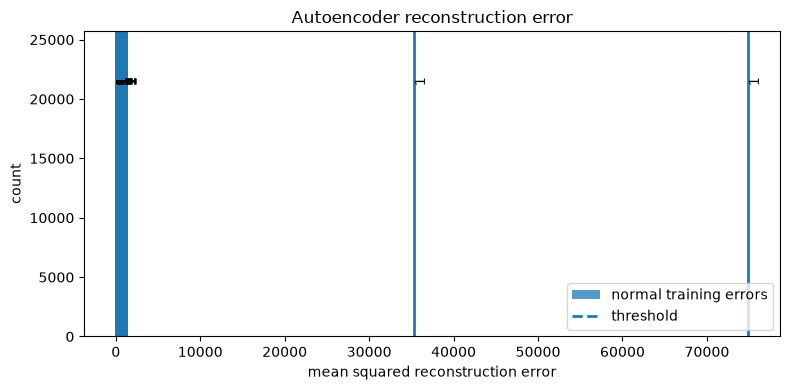

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(normal_errors, bins=25, alpha=0.75, label="normal training errors")
ax.axvline(threshold, linestyle="--", linewidth=2, label="threshold")

for _, row in ae_df[ae_df["label"] == 1].iterrows():
    ax.axvline(row["autoencoder_reconstruction_error"], linewidth=2)
    ax.text(
        row["autoencoder_reconstruction_error"],
        ax.get_ylim()[1] * 0.85,
        row["label"],
        rotation=90,
        va="top"
    )

ax.set_title("Autoencoder reconstruction error")
ax.set_xlabel("mean squared reconstruction error")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

In [393]:
feature_level_error = pd.DataFrame(
    (x_eval_trans - X_reconstructed) ** 2,
    columns=x_eval.columns
)

feature_level_error["total_error"] = ae_df["autoencoder_reconstruction_error"].values
feature_level_error["label"] = ae_df["label"].values

feature_level_error.sort_values("total_error", ascending=False).head(5).round(3)

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,total_error,label
38681,3445661.573,2.744,5.244,2.885,1.278,1.278,0.0,0.0,0.001,0.0,0.003,4.117,0.0,0.0,0.335,2.673,0.000,0.004,2.371,0.084,5.155,0.698,0.0,0.0,0.0,0.0,3.633,0.029,0.0,0.260,0.0,0.514,0.514,0.104,0.945,0.148,0.148,0.176,0.331,6.550,6.555,0.160,0.173,0.149,4.390,6.547,74906.995,1
7072,1626365.651,3.203,0.036,0.057,1.279,1.279,0.0,0.0,0.001,0.0,0.003,4.117,0.0,0.0,0.335,1.250,0.000,0.007,2.356,0.084,5.155,0.698,0.0,0.0,0.0,0.0,3.633,0.029,0.0,0.260,0.0,0.514,0.514,0.021,0.939,0.063,0.361,0.061,0.979,0.314,0.315,0.675,0.060,0.141,2.810,0.312,35356.468,1
990,0.871,0.918,20.529,7.607,27089.548,27089.548,0.0,0.0,0.011,0.0,66.077,24.988,0.0,0.0,0.076,0.522,0.005,0.263,1.165,1.348,4.945,1.230,0.0,0.0,0.0,0.0,25.540,17.400,0.0,1.889,0.0,1.696,1.696,3.187,9.229,8.813,14.285,8.512,10.275,8.436,8.524,12.937,8.523,7.323,15.355,8.539,1184.387,1
21964,0.864,0.910,45.488,7.669,27088.766,27088.766,0.0,0.0,0.011,0.0,0.034,4.805,0.0,0.0,0.079,0.519,0.005,0.260,1.158,1.360,4.945,1.234,0.0,0.0,0.0,0.0,4.635,17.420,0.0,1.904,1.0,1.705,1.706,3.279,9.598,8.941,14.610,8.599,10.530,8.583,8.685,13.609,8.610,7.402,15.263,8.700,1182.645,1
1523,0.864,0.910,45.488,7.669,27088.766,27088.766,0.0,0.0,0.011,0.0,0.034,4.805,0.0,0.0,0.079,0.519,0.005,0.260,1.158,1.360,4.945,1.234,0.0,0.0,0.0,0.0,4.635,17.420,0.0,1.904,1.0,1.705,1.706,3.279,9.598,8.941,14.610,8.599,10.530,8.583,8.685,13.609,8.610,7.402,15.263,8.700,1182.645,1


# 11. Final Method Comparison and Alert Triage